In [3]:
import pandas as pd
df = pd.read_csv("/Users/ENPC/cours 3/3 MCNDU/projet/comptages-routiers-permanents.csv", sep=";")
df.head(10)

,Identifiant arc,Libelle,Date et heure de comptage,Débit horaire,Taux d'occupation,Etat trafic,Identifiant noeud amont,Libelle noeud amont,Identifiant noeud aval,Libelle noeud aval,Etat arc,Date debut dispo data,Date fin dispo data,geo_point_2d,geo_shape
0,5325,PE_Reuilly,2024-10-04T21:00:00+02:00,5955.0,18.70000,Pré-saturé,528,SE_Charenton,2818,PE_Daumesnil,Ouvert,1996-10-28,2023-01-01,"48.83194119399435, 2.4051573651790856","{""coordinates"": [[2.4024737927921205, 48.83032..."
1,829,Bd_Gal_de_Gaulle (le_Kremlin),2024-11-03T14:00:00+01:00,NaN,24.60056,Pré-saturé,467,A6b_Elisee_Reclus,475,Pte_d'Italie-PE_RN7,Invalide,1996-10-03,2023-01-01,"48.815888020936654, 2.3587275983847618","{""coordinates"": [[2.3567660737758693, 48.81589..."
2,4010,Av_de_Clichy,2024-12-04T14:00:00+01:00,223.0,13.72667,Fluide,2037,Av_de_Clichy-Moquet,2029,Av_de_Clichy-Bodin,Invalide,1996-10-03,2023-01-01,"48.89143424973461, 2.3188079239898496","{""coordinates"": [[2.319083026525339, 48.891285..."
3,1067,Quai_d'Issy,2025-01-11T19:00:00+01:00,769.0,4.43000,Fluide,560,Quai_Andre_Citroen-am_Victor,593,Quai_Issy_Y-Echangeur_Garigliano,Invalide,1996-10-03,2023-01-01,"48.839727155124635, 2.2702033361716216","{""coordinates"": [[2.2710888497739044, 48.84038..."
4,5460,SI_Passy,2025-02-18T22:00:00+01:00,NaN,NaN,Inconnu,2856,SI_Passy,2864,Lacs_a_Passy-Fortifications-BP,Ouvert,1996-11-06,2023-01-01,"48.85791852282797, 2.26121220748304","{""coordinates"": [[2.2595195177162712, 48.85777..."
5,1505,Bd_Serurier,2025-03-01T16:00:00+01:00,NaN,13.19611,Fluide,801,Bd_Serurier-Zenith,800,Pte_Pantin-Av_Jean_Jaures,Ouvert,1996-10-03,2023-01-01,"48.8901422986812, 2.395358469298637","{""coordinates"": [[2.3952921264732994, 48.89041..."
6,5935,Bd_de_Clichy,2025-04-01T12:00:00+02:00,NaN,19.32444,Pré-saturé,3083,Clichy-Fromentin,3082,Place_Blanche,Ouvert,1997-09-23,2023-01-01,"48.88355607796193, 2.33384205686592","{""coordinates"": [[2.3350348765599707, 48.88321..."
7,4621,Souterrain_Invalides_VGP,2025-05-06T19:00:00+02:00,1895.0,7.09278,Fluide,2467,Cours_Albert_Ier-VGP,163,Souterrain_Cours_la_Reine,Ouvert,1996-10-16,2023-01-01,"48.86459640905526, 2.3052956227920625","{""coordinates"": [[2.3035318372669678, 48.86455..."
8,1,Quai_du_Louvre,2025-06-04T23:00:00+02:00,NaN,NaN,Inconnu,1,Pt_Carrousel_Droite,0,Quai_du_Louvre_(Musee),Invalide,1996-10-03,2023-01-01,"48.85983845714678, 2.3342418168659105","{""coordinates"": [[2.3334197551070197, 48.86002..."
9,5167,Georges_Lafont,2025-07-03T19:00:00+02:00,NaN,NaN,Inconnu,2729,Pte_St_Cloud-Av_Georges_Lafont,2496,Pte_St_Cloud,Invalide,2005-01-01,2019-06-01,"48.8366229487094, 2.2560428588437764","{""coordinates"": [[2.256125519339524, 48.836758..."


In [5]:
df['Date et heure de comptage'].min()

'2024-10-01T05:00:00+02:00'

In [3]:
df = df.dropna(subset=['Débit horaire', "Taux d'occupation"], how='all')

In [5]:
df['Identifiant arc'].nunique()

2248

In [7]:
df['Libelle'].nunique()

637

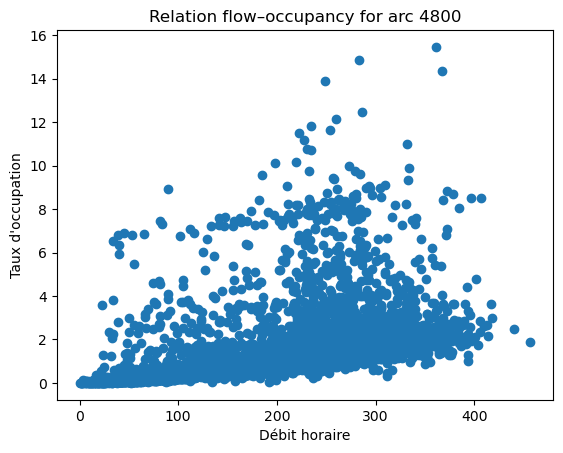

In [33]:
import matplotlib.pyplot as plt

arc_id = 4800
temp = df[df['Identifiant arc'] == arc_id]
plt.scatter(temp['Débit horaire'], temp['Taux d\'occupation'])
plt.xlabel("Débit horaire")
plt.ylabel("Taux d'occupation")
plt.title(f"Relation flow–occupancy for arc {arc_id}")
plt.show()

In [7]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

def fill_occupancy_by_arc(df):
    df_filled = df.copy()
    for arc_id in df['Identifiant arc'].unique():
        arc_data = df[df['Identifiant arc'] == arc_id]
        # train set and prediction set
        train_data = arc_data.dropna(subset=['Taux d\'occupation'])
        missing_data = arc_data[arc_data['Taux d\'occupation'].isna()]
        
        if len(train_data) < 5:
            continue
        
        X_train = train_data[['Débit horaire']]
        y_train = train_data['Taux d\'occupation']
        model = RandomForestRegressor(n_estimators=100,random_state=42)
        model.fit(X_train, y_train)
        
        if len(missing_data) > 0:
            X_pred = missing_data[['Débit horaire']]
            y_pred = model.predict(X_pred)
            df_filled.loc[(df_filled['Identifiant arc'] == arc_id) &(df_filled['Taux d\'occupation'].isna()),'Taux d\'occupation'] = y_pred
    return df_filled

df_filled = fill_occupancy_by_arc(df)

In [9]:
df_clean = df_filled.dropna(subset=["Taux d'occupation"])
print(df_clean['Libelle'].nunique())
print(df_clean['Identifiant arc'].nunique())

614
1953


In [11]:
arc_counts = df_clean.groupby("Identifiant arc").size().reset_index(name="n_observations")
print(arc_counts["n_observations"].describe())

count    1953.000000
mean     8476.592422
std      1360.672012
min         1.000000
25%      8691.000000
50%      8699.000000
75%      8699.000000
max      8715.000000
Name: n_observations, dtype: float64


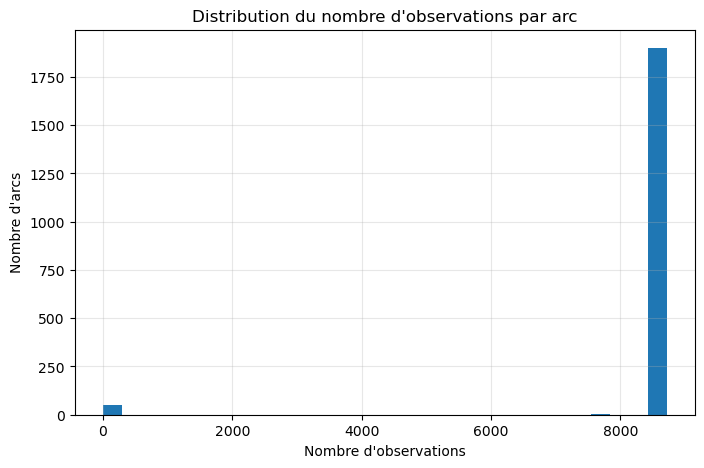

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(arc_counts["n_observations"], bins=30)
plt.title("Distribution du nombre d'observations par arc")
plt.xlabel("Nombre d'observations")
plt.ylabel("Nombre d'arcs")
plt.grid(alpha=0.3)
plt.show()